# 01 - Exploratory Data Analysis (EDA)
## CheXpert: Chest X-Ray Disease Detection

This notebook explores the CheXpert dataset that we will use to train
a CNN model for multi-label classification of diseases in chest X-ray images.

Dataset: CheXpert-v1.0-small (from Kaggle)  
Number of images: 224,000 chest X-rays  
Number of classes: 14 possible conditions  

In [1]:
import kagglehub
import os

# Download CheXpert dataset
path = kagglehub.dataset_download("ashery/chexpert")
print("Data downloaded to:", path)

Data downloaded to: C:\Users\magne\.cache\kagglehub\datasets\ashery\chexpert\versions\1


## 1. Import libraries
We use Keras (with TensorFlow as backend) for deep learning, Pandas for
data handling, and Matplotlib/Seaborn for visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("Libraries loaded!")

Libraries loaded!


## 2. Load data
CheXpert comes with a CSV file for training and validation data.
Each row represents one image with corresponding labels for 14 conditions.
Labels are encoded as:
- 1 = Positive (condition present)
- 0 = Negative (condition absent)
- -1 = Uncertain
- NaN = Not mentioned in the radiology report

In [3]:
# Load training and validation data
train_df = pd.read_csv(os.path.join(path, "train.csv"))
valid_df = pd.read_csv(os.path.join(path, "valid.csv"))

print("Training data shape:", train_df.shape)
print("Validation data shape:", valid_df.shape)
print("\nColumns:", train_df.columns.tolist())
train_df.head()

Training data shape: (223414, 19)
Validation data shape: (234, 19)

Columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


## 3. Label distribution
We investigate how many positive, negative and uncertain cases there are
per condition. This is important for understanding class imbalance in the dataset.

In [4]:
# The 14 conditions we are classifying
conditions = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

# Count positive (1), negative (0) and uncertain (-1) per condition
label_counts = train_df[conditions].apply(pd.Series.value_counts).T
label_counts.columns = ['Uncertain (-1)', 'Negative (0)', 'Positive (1)']
label_counts = label_counts.fillna(0).astype(int)

print(label_counts)

                            Uncertain (-1)  Negative (0)  Positive (1)
No Finding                               0             0         22381
Enlarged Cardiomediastinum           12403         21638         10798
Cardiomegaly                          8087         11116         27000
Lung Opacity                          5598          6599        105581
Lung Lesion                           1488          1270          9186
Edema                                12984         20726         52246
Consolidation                        27742         28097         14783
Pneumonia                            18770          2799          6039
Atelectasis                          33739          1328         33376
Pneumothorax                          3145         56341         19448
Pleural Effusion                     11628         35396         86187
Pleural Other                         2653           316          3523
Fracture                               642          2512          9040
Suppor

## 4. Visualizing label distribution
A bar chart gives us a quick overview of which conditions are most and
least common in the training data.

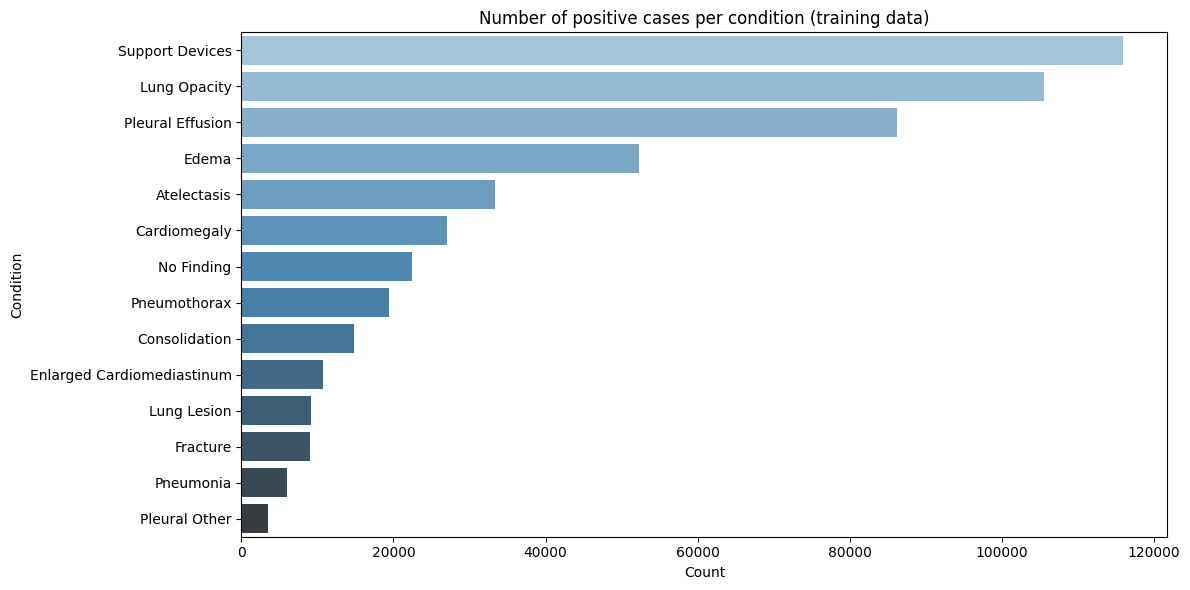

In [5]:
# Visualize number of positive cases per condition
positive_counts = (train_df[conditions] == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=positive_counts.values, y=positive_counts.index, hue=positive_counts.index, legend=False, palette="Blues_d")
plt.title("Number of positive cases per condition (training data)")
plt.xlabel("Count")
plt.ylabel("Condition")
plt.tight_layout()
plt.savefig("../results/figures/label_distribution.png")
plt.show()

## 5. Sample X-ray images
We visualize some random images from the dataset to get an understanding
of image quality and how the conditions appear visually.

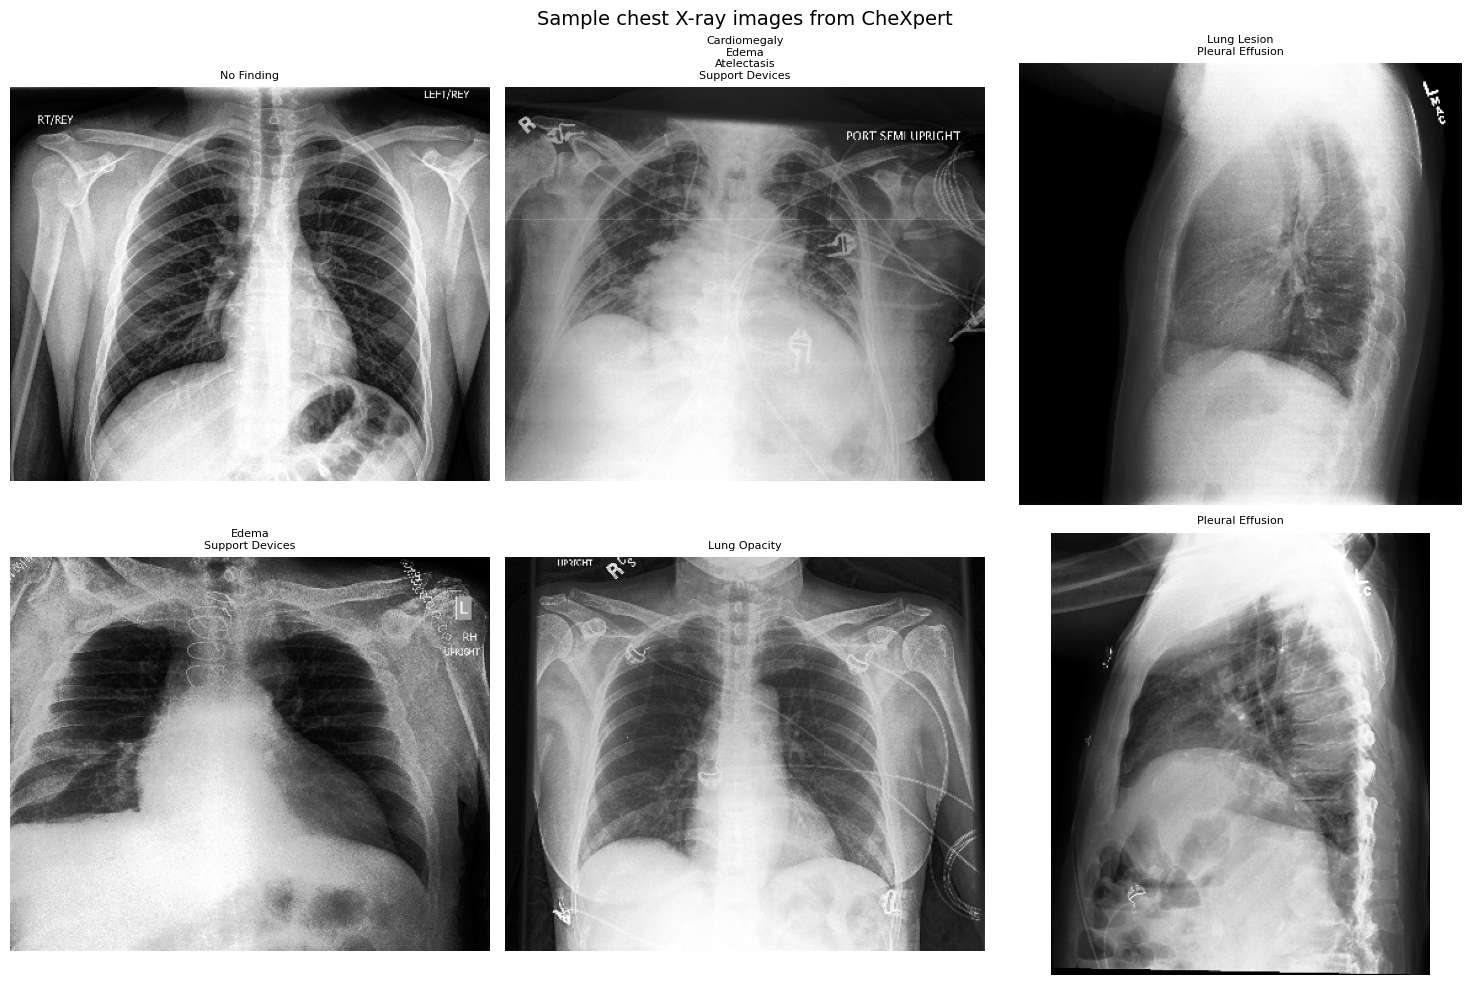

In [6]:
# Display 6 random chest X-ray images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sample = train_df.sample(6, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):
    # Fix image path
    relative_path = row['Path'].replace("CheXpert-v1.0-small/", "")
    img_path = os.path.join(path, relative_path)
    img = Image.open(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    # Show which conditions are present
    labels = [c for c in conditions if row[c] == 1]
    axes[i].set_title('\n'.join(labels) if labels else 'No Finding', fontsize=8)

plt.suptitle("Sample chest X-ray images from CheXpert", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/sample_images.png")
plt.show()

## 6. Missing values
NaN values in CheXpert mean that a condition was not mentioned in the
radiology report. This is not the same as negative, it is an important
distinction when we later train the model.

In [7]:
# Check for NaN values in labels
print("Missing values per column:")
print(train_df[conditions].isna().sum().sort_values(ascending=False))

print("\nLabel value explanation:")
print("-1 = Uncertain")
print(" 0 = Negative (not present)")
print(" 1 = Positive (present)")
print("NaN = Not mentioned in the radiology report")

Missing values per column:
Pleural Other                 216922
Lung Lesion                   211470
Fracture                      211220
No Finding                    201033
Pneumonia                     195806
Enlarged Cardiomediastinum    178575
Cardiomegaly                  177211
Atelectasis                   154971
Consolidation                 152792
Pneumothorax                  144480
Edema                         137458
Lung Opacity                  105636
Support Devices               100197
Pleural Effusion               90203
dtype: int64

Label value explanation:
-1 = Uncertain
 0 = Negative (not present)
 1 = Positive (present)
NaN = Not mentioned in the radiology report


## 7. Summary
Key statistics from the dataset that give us a good starting point
before we begin training models.

In [8]:
print("Dataset summary:")
print(f"Number of training images: {len(train_df)}")
print(f"Number of validation images: {len(valid_df)}")
print(f"Number of unique patients: {train_df['Path'].str.split('/').str[2].nunique()}")
print(f"\nMost common condition: {positive_counts.index[0]} ({positive_counts.iloc[0]} cases)")
print(f"Least common condition: {positive_counts.index[-1]} ({positive_counts.iloc[-1]} cases)")

Dataset summary:
Number of training images: 223414
Number of validation images: 234
Number of unique patients: 64540

Most common condition: Support Devices (116001 cases)
Least common condition: Pleural Other (3523 cases)


Note: "Support Devices" is not a disease, but medical equipment visible
in the X-ray (breathing tubes, pacemakers, etc.). That this is the most
common "class" indicates that many images were taken of critically ill
hospitalized patients.